In [1]:
!pip install nbformat

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



---

# Polynomial Logistic Regression – Mathematical Formulation

## 1. Polynomial Feature Transformation

First we transform the original features into **polynomial features**.

Suppose the original input vector is:

$$
x = [x_1, x_2]
$$

For **degree = 2**, the polynomial feature vector becomes:

$$
\phi(x) =
[1, x_1, x_2, x_1^2, x_2^2, x_1x_2]
$$

Where:

* $x_1, x_2$ = original features
* $1$ = bias feature
* $\phi(x)$ = transformed polynomial feature vector

---

## 2. Feature Matrix

If we have **m samples**, the dataset becomes a matrix:

$$
X =
\begin{bmatrix}
1 & x_{11} & x_{12} & x_{11}^2 & x_{12}^2 & x_{11}x_{12} \
1 & x_{21} & x_{22} & x_{21}^2 & x_{22}^2 & x_{21}x_{22} \
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots \
1 & x_{m1} & x_{m2} & x_{m1}^2 & x_{m2}^2 & x_{m1}x_{m2}
\end{bmatrix}
$$

Matrix shape:

$$
X \in \mathbb{R}^{m \times p}
$$

Where:

* $m$ = number of samples
* $p$ = number of polynomial features

For degree 2 with 2 variables:

$$
p = 6
$$

So the matrix shape is:

$$
X = (m \times 6)
$$

---

# 3. Linear Model

We compute the linear combination:

$$
z = XW
$$

Where:

* $X$ = feature matrix $(m \times p)$
* $W$ = weight vector $(p \times 1)$

Weight vector:

$$
W =
\begin{bmatrix}
w_0 \
w_1 \
w_2 \
w_3 \
w_4 \
w_5
\end{bmatrix}
$$

Shape:

$$
W = (p \times 1)
$$

Matrix multiplication:

$$
(m \times p) \times (p \times 1)
$$

Result:

$$
z = (m \times 1)
$$

So each sample gets **one output value**.

---

# 4. Sigmoid Function

The linear output is converted into probability using the **sigmoid function**.

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

Predicted probability:

$$
\hat{y} = \sigma(z)
$$

Shape:

$$
\hat{y} = (m \times 1)
$$

Where:

* $\hat{y}$ = predicted probability
* values range between **0 and 1**

---

# 5. Loss Function (Binary Cross Entropy)

Logistic regression uses **log loss**.

$$
J(W) =
-\frac{1}{m}
\sum_{i=1}^{m}
\left[
y_i \log(\hat{y}_i) +
(1-y_i)\log(1-\hat{y}_i)
\right]
$$

Where:

* $m$ = number of samples
* $y_i$ = true label
* $\hat{y}_i$ = predicted probability

---

# 6. Gradient Calculation

Gradient of the loss with respect to weights:

$$
\frac{\partial J}{\partial W}
=============================

\frac{1}{m}
X^T(\hat{y} - y)
$$

Shapes:

$$
X^T = (p \times m)
$$

$$
(\hat{y} - y) = (m \times 1)
$$

Matrix multiplication:

$$
(p \times m) \times (m \times 1)
$$

Result:

$$
gradient = (p \times 1)
$$

---

# 7. Gradient Descent Update

Weights are updated iteratively:

$$
W = W - \alpha \cdot gradient
$$

Where:

* $\alpha$ = learning rate

Weight shape remains:

$$
(p \times 1)
$$

---

# 8. Prediction Rule

Final classification rule:

$$
\hat{y} =
\begin{cases}
1 & \text{if } \sigma(z) \ge 0.5 \
0 & \text{if } \sigma(z) < 0.5
\end{cases}
$$

---

# 9. Training Procedure

Steps:

1. Transform input features into **polynomial features**
2. Initialize weight vector $W$
3. Compute linear output

$$
z = XW
$$

4. Apply sigmoid

$$
\hat{y} = \sigma(z)
$$

5. Compute loss using **log loss**
6. Compute gradient

$$
\frac{1}{m}X^T(\hat{y}-y)
$$

7. Update weights using gradient descent
8. Repeat until convergence

---

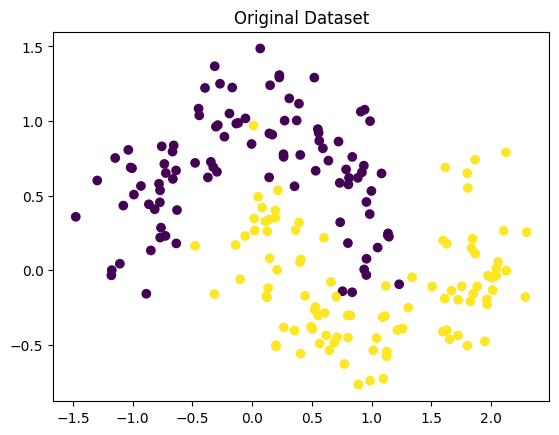

Original shape: (200, 2)
Polynomial shape: (200, 5)
Accuracy: 0.85


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# --------------------------------
# 1. Create nonlinear dataset
# --------------------------------
X, y = make_moons(n_samples=200, noise=0.2, random_state=42)

plt.scatter(X[:,0], X[:,1], c=y)
plt.title("Original Dataset")
plt.show()

y = y.reshape(-1,1)

# --------------------------------
# 2. Manually Create Polynomial Features
# --------------------------------

x1 = X[:,0].reshape(-1,1)
x2 = X[:,1].reshape(-1,1)

x1_square = x1**2
x2_square = x2**2
x1x2 = x1 * x2

X_poly = np.hstack((x1, x2, x1_square, x2_square, x1x2))

print("Original shape:", X.shape)
print("Polynomial shape:", X_poly.shape)

# --------------------------------
# 3. Sigmoid Function
# --------------------------------
def sigmoid(z):
    return 1/(1 + np.exp(-z))

# --------------------------------
# 4. Initialize Weights
# --------------------------------
m, n = X_poly.shape

W = np.zeros((n,1))

learning_rate = 0.1
epochs = 5000

# --------------------------------
# 5. Gradient Descent Training
# --------------------------------
for i in range(epochs):

    z = np.dot(X_poly, W)

    y_hat = sigmoid(z)

    gradient = (1/m) * np.dot(X_poly.T, (y_hat - y))

    W = W - learning_rate * gradient

# --------------------------------
# 6. Prediction Function
# --------------------------------
def predict(X):

    x1 = X[:,0].reshape(-1,1)
    x2 = X[:,1].reshape(-1,1)

    x1_square = x1**2
    x2_square = x2**2
    x1x2 = x1 * x2

    X_poly = np.hstack((x1, x2, x1_square, x2_square, x1x2))

    z = np.dot(X_poly, W)

    probs = sigmoid(z)

    return (probs >= 0.5).astype(int)

# --------------------------------
# 7. Test Accuracy
# --------------------------------
y_pred = predict(X)

accuracy = np.mean(y_pred == y)

print("Accuracy:", accuracy)

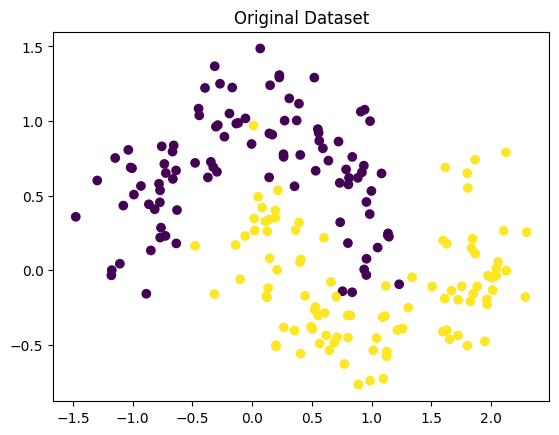

Epoch: 0
Loss: 0.6931471785599453
Accuracy: 0.5
w0: 0.024909190974605255
w1: -0.018826199983504613
w3: -0.010881391312541329


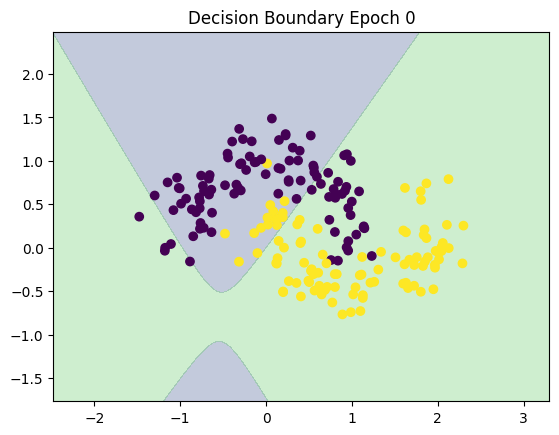

Epoch: 100
Loss: 0.38821790201942635
Accuracy: 0.835
w0: 0.7870537297704666
w1: -1.132527807195786
w3: -0.6370327644627147


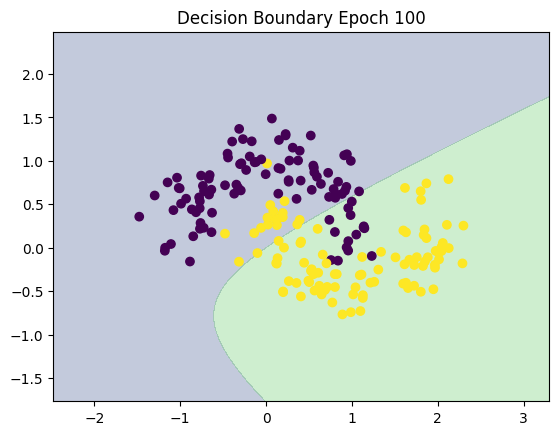

Epoch: 200
Loss: 0.34941340601712156
Accuracy: 0.84
w0: 1.0433111832351734
w1: -1.6254383047776477
w3: -0.8479948764962828


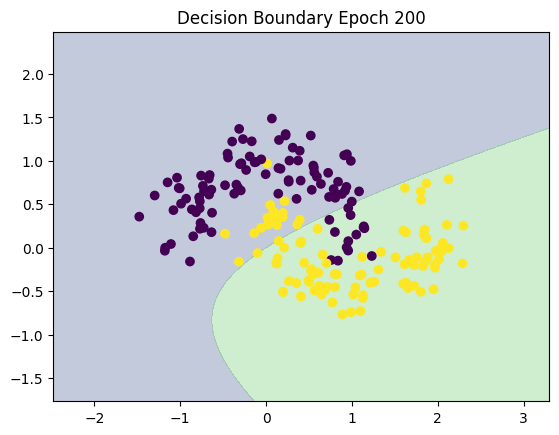

Epoch: 300
Loss: 0.33658603967256395
Accuracy: 0.84
w0: 1.1912130086060617
w1: -1.9215442324560656
w3: -0.9439350668610734


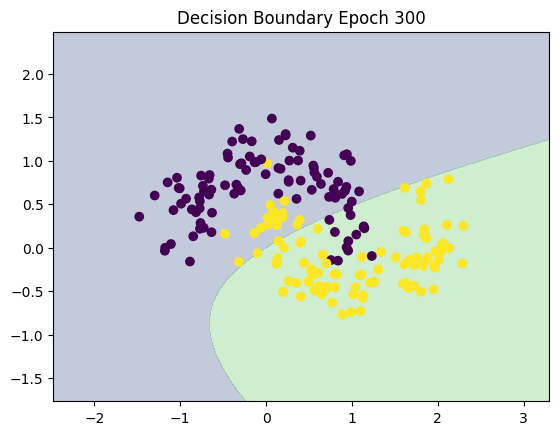

Epoch: 400
Loss: 0.33107189651006474
Accuracy: 0.84
w0: 1.286088539639891
w1: -2.1233902551421435
w3: -0.9898847800839814


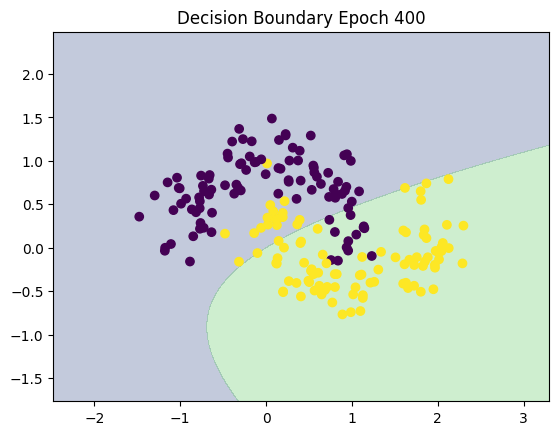

Epoch: 500
Loss: 0.3283288034999109
Accuracy: 0.84
w0: 1.349858258875272
w1: -2.271006915400584
w3: -1.0088836837927404


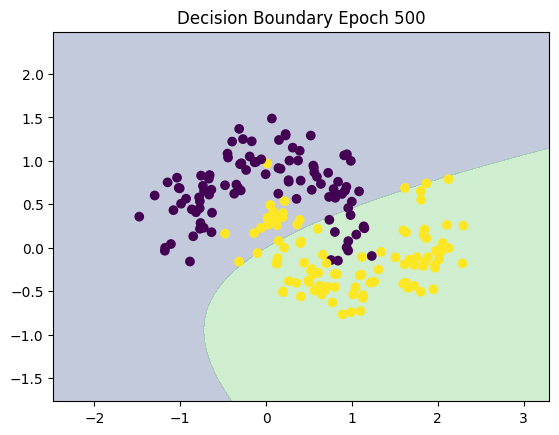

Epoch: 600
Loss: 0.32681137874037197
Accuracy: 0.84
w0: 1.3936735757363248
w1: -2.384169770858147
w3: -1.0116367774463455


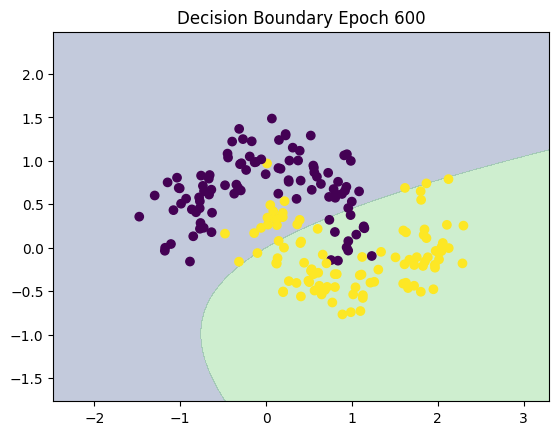

Epoch: 700
Loss: 0.32589042922026834
Accuracy: 0.84
w0: 1.4239860203440553
w1: -2.4740567490169907
w3: -1.003951507657104


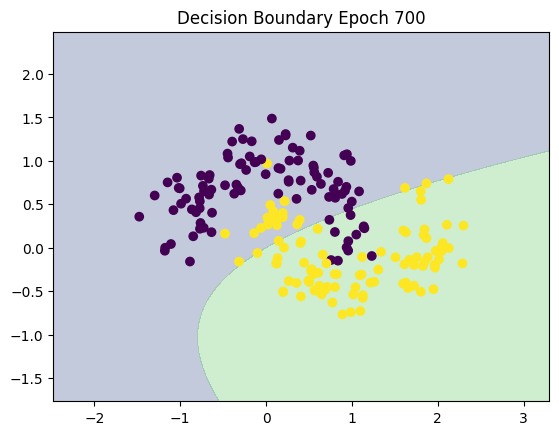

Epoch: 800
Loss: 0.32527971754025714
Accuracy: 0.84
w0: 1.4448410224737638
w1: -2.5475558467422346
w3: -0.9893048447793518


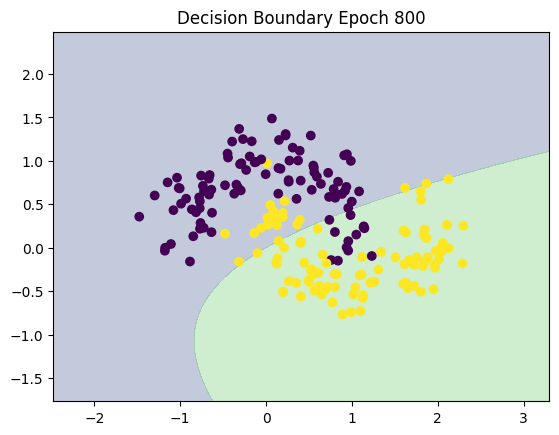

Epoch: 900
Loss: 0.3248389968876941
Accuracy: 0.84
w0: 1.458917518152351
w1: -2.6091699645312496
w3: -0.9699223580408014


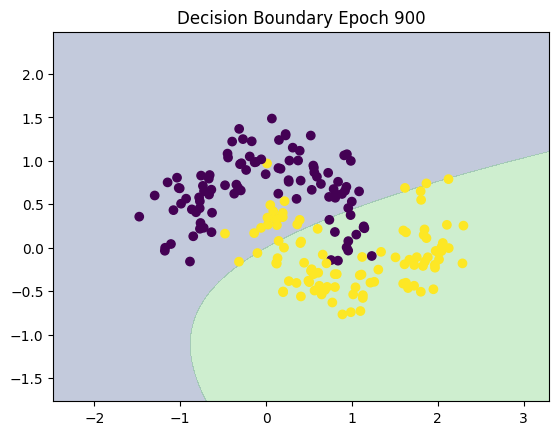

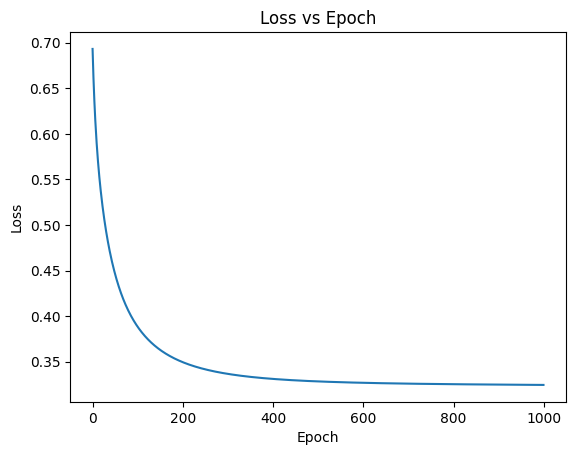

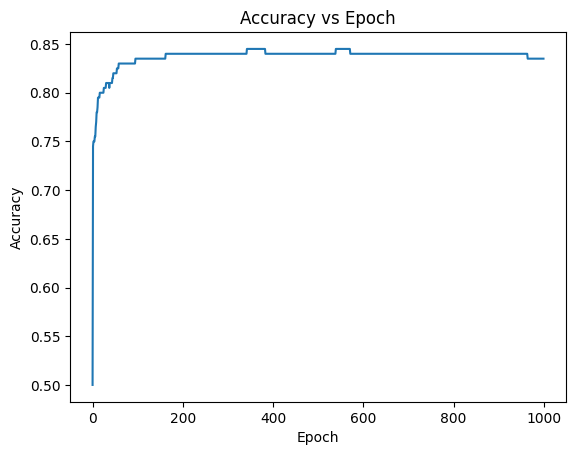

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# --------------------------------
# 1. Create nonlinear dataset
# --------------------------------
X, y = make_moons(n_samples=200, noise=0.2, random_state=42)

plt.scatter(X[:,0], X[:,1], c=y)
plt.title("Original Dataset")
plt.show()

y = y.reshape(-1,1)

# --------------------------------
# 2. Manual Polynomial Features
# --------------------------------
def polynomial_features(X):

    x1 = X[:,0].reshape(-1,1)
    x2 = X[:,1].reshape(-1,1)

    x1_sq = x1**2
    x2_sq = x2**2
    x1x2 = x1*x2

    return np.hstack((x1, x2, x1_sq, x2_sq, x1x2))

X_poly = polynomial_features(X)

# --------------------------------
# 3. Sigmoid
# --------------------------------
def sigmoid(z):
    return 1/(1 + np.exp(-z))

# --------------------------------
# 4. Loss Function
# --------------------------------
def loss_function(y, y_hat):

    m = len(y)

    loss = -(1/m)*np.sum(
        y*np.log(y_hat+1e-9) + (1-y)*np.log(1-y_hat+1e-9)
    )

    return loss

# --------------------------------
# 5. Accuracy Function
# --------------------------------
def accuracy(y, y_pred):

    return np.mean(y == y_pred)

# --------------------------------
# 6. Initialize Parameters
# --------------------------------
m,n = X_poly.shape

W = np.zeros((n,1))

lr = 0.1
epochs = 1000

loss_history = []
acc_history = []

# --------------------------------
# 7. Decision Boundary Function
# --------------------------------
def plot_boundary(W, epoch):

    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_poly = polynomial_features(grid)

    Z = sigmoid(np.dot(grid_poly, W))
    Z = Z.reshape(xx.shape)

    plt.contourf(xx,yy,Z,levels=[0,0.5,1],alpha=0.3)
    plt.scatter(X[:,0],X[:,1],c=y)

    plt.title(f"Decision Boundary Epoch {epoch}")
    plt.show()

# --------------------------------
# 8. Training Loop
# --------------------------------
for epoch in range(epochs):

    # Forward
    z = np.dot(X_poly,W)
    y_hat = sigmoid(z)

    # Loss
    loss = loss_function(y,y_hat)
    loss_history.append(loss)

    # Prediction
    y_pred = (y_hat >= 0.5).astype(int)

    # Accuracy
    acc = accuracy(y,y_pred)
    acc_history.append(acc)

    # Gradient
    gradient = (1/m)*np.dot(X_poly.T,(y_hat-y))

    # Update
    W = W - lr*gradient

    # Every 100 epochs
    if epoch % 100 == 0:

        print("Epoch:",epoch)
        print("Loss:",loss)
        print("Accuracy:",acc)

        print("w0:",W[0][0])
        print("w1:",W[1][0])
        print("w3:",W[3][0])

        plot_boundary(W,epoch)

# --------------------------------
# 9. Plot Loss
# --------------------------------
plt.plot(loss_history)
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# --------------------------------
# 10. Plot Accuracy
# --------------------------------
plt.plot(acc_history)
plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

##Using sklearn plz

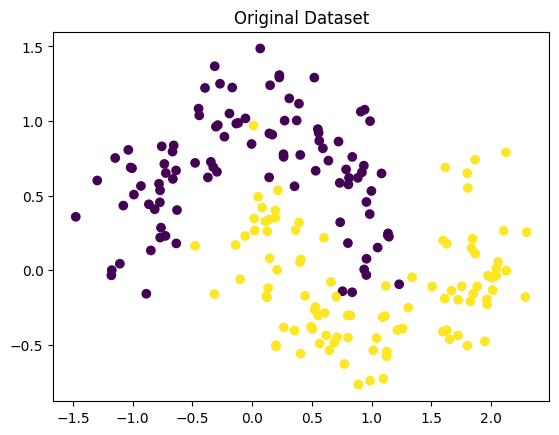

Original shape: (200, 2)
Polynomial shape: (200, 5)
Accuracy: 0.84
Intercept (w0): [0.41101592]
Weights: [[ 1.20024942 -2.74152639  0.00453296 -0.86535632 -0.16954058]]


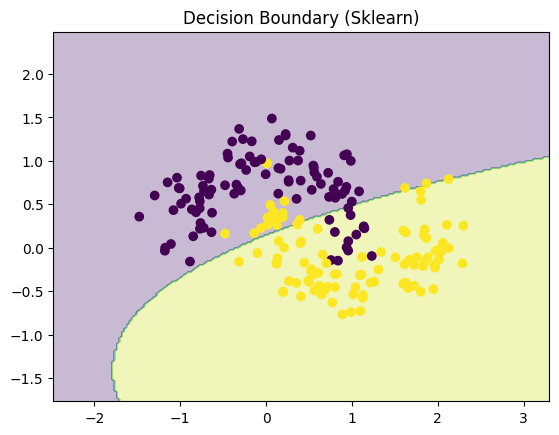

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.linear_model import LogisticRegression

# --------------------------------
# 1. Create nonlinear dataset
# --------------------------------
X, y = make_moons(n_samples=200, noise=0.2, random_state=42)

plt.scatter(X[:,0], X[:,1], c=y)
plt.title("Original Dataset")
plt.show()

# --------------------------------
# 2. Manually Create Polynomial Features
# --------------------------------

x1 = X[:,0].reshape(-1,1)
x2 = X[:,1].reshape(-1,1)

x1_square = x1**2
x2_square = x2**2
x1x2 = x1 * x2

X_poly = np.hstack((x1, x2, x1_square, x2_square, x1x2))

print("Original shape:", X.shape)
print("Polynomial shape:", X_poly.shape)

# --------------------------------
# 3. Train Logistic Regression
# --------------------------------

model = LogisticRegression()

model.fit(X_poly, y)

# --------------------------------
# 4. Predictions
# --------------------------------

y_pred = model.predict(X_poly)

accuracy = np.mean(y_pred == y)

print("Accuracy:", accuracy)

# --------------------------------
# 5. Model Parameters
# --------------------------------

print("Intercept (w0):", model.intercept_)
print("Weights:", model.coef_)

# --------------------------------
# 6. Decision Boundary
# --------------------------------

def polynomial_features(X):

    x1 = X[:,0].reshape(-1,1)
    x2 = X[:,1].reshape(-1,1)

    x1_square = x1**2
    x2_square = x2**2
    x1x2 = x1 * x2

    return np.hstack((x1, x2, x1_square, x2_square, x1x2))

x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid = np.c_[xx.ravel(), yy.ravel()]
grid_poly = polynomial_features(grid)

Z = model.predict(grid_poly)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:,0], X[:,1], c=y)

plt.title("Decision Boundary (Sklearn)")
plt.show()

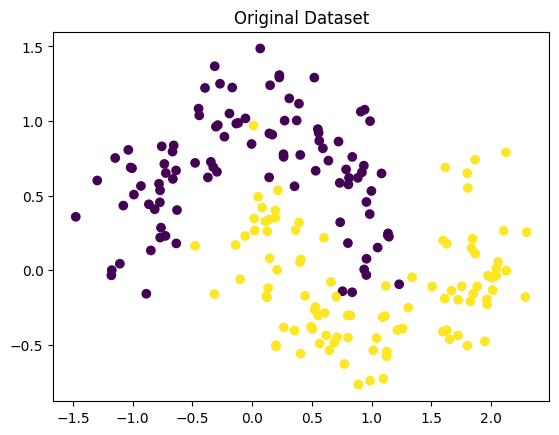


Polynomial Degree: 1
Original shape: (200, 2)
Polynomial shape: (200, 3)
Accuracy: 0.85
Intercept (w0): [0.33683387]
Weights: [[-7.90909149e-04  1.14233369e+00 -3.17932852e+00]]


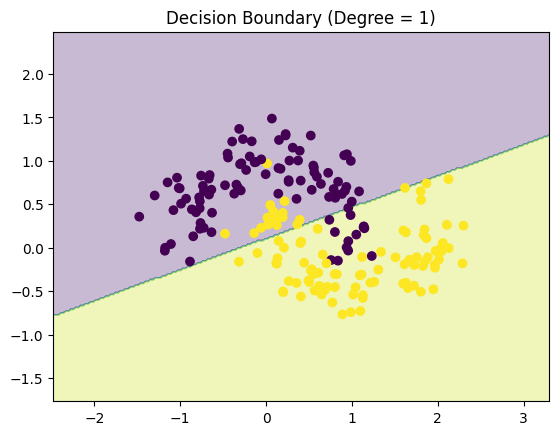


Polynomial Degree: 2
Original shape: (200, 2)
Polynomial shape: (200, 6)
Accuracy: 0.84
Intercept (w0): [0.41044518]
Weights: [[ 1.52828271e-03  1.20119492e+00 -2.74732860e+00  3.72670471e-03
  -1.70844737e-01 -8.59909959e-01]]


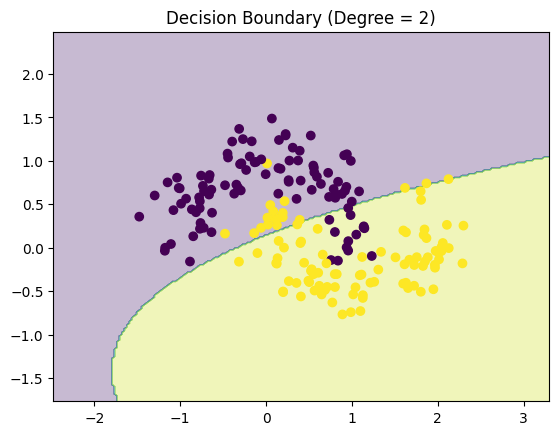


Polynomial Degree: 3
Original shape: (200, 2)
Polynomial shape: (200, 10)
Accuracy: 0.945
Intercept (w0): [1.49271987]
Weights: [[ 6.63663696e-04 -3.80736057e-01 -2.50675847e+00 -2.71648207e+00
  -4.24357470e-01 -6.63618091e-01  2.19617722e+00 -5.56781793e-01
   6.86970977e-01 -1.16347935e+00]]


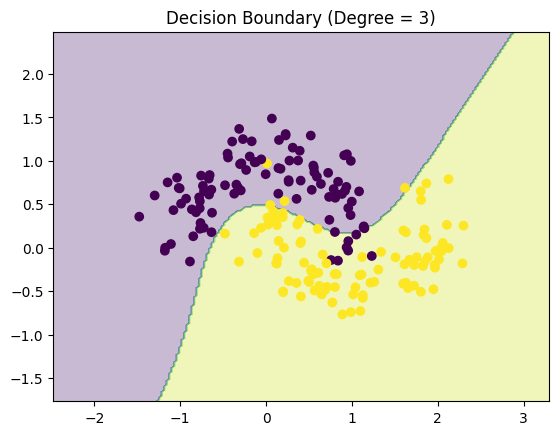


Polynomial Degree: 5
Original shape: (200, 2)
Polynomial shape: (200, 21)
Accuracy: 0.97
Intercept (w0): [1.76970434]
Weights: [[ 1.46723196e-04  3.53081920e-01 -2.35188527e+00 -2.78466962e+00
  -5.43666780e-01 -6.59300325e-01 -2.37239037e-01 -1.32890770e+00
   4.11810984e-01 -9.76842886e-01 -8.92142766e-01 -2.16120601e-01
  -3.32967648e-02 -1.02626833e-01 -4.28073286e-01  1.66292643e+00
  -1.26001664e-01  6.18721555e-01 -2.87830408e-01  9.64697941e-02
  -3.87871117e-01]]


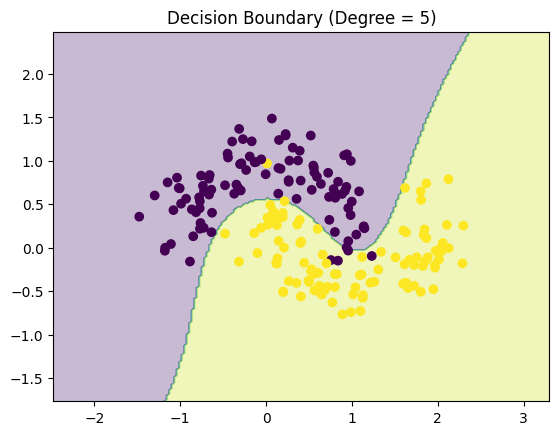


Polynomial Degree: 8
Original shape: (200, 2)
Polynomial shape: (200, 45)
Accuracy: 0.975
Intercept (w0): [1.7914775]
Weights: [[ 0.01536797  0.80129878 -2.19576226 -2.34909243 -0.41371339 -0.7697909
  -0.10087526 -1.27813289  0.2624519  -0.95442825 -1.4653463  -0.44086282
  -0.25264798 -0.14839749 -0.43914978  0.01126004 -0.75320008  0.19606038
  -0.38520965  0.01931083 -0.35173877 -0.61359924 -0.36346375  0.04390219
  -0.08917667 -0.15048995 -0.06550314 -0.14348133  0.59143095 -0.44667685
   0.27086699 -0.14868438  0.0411458  -0.17063486 -0.01313354 -0.07782642
   0.61005519 -0.1237197   0.26870488 -0.02050751  0.00538076 -0.02684409
  -0.09694629 -0.03400703  0.00780094]]


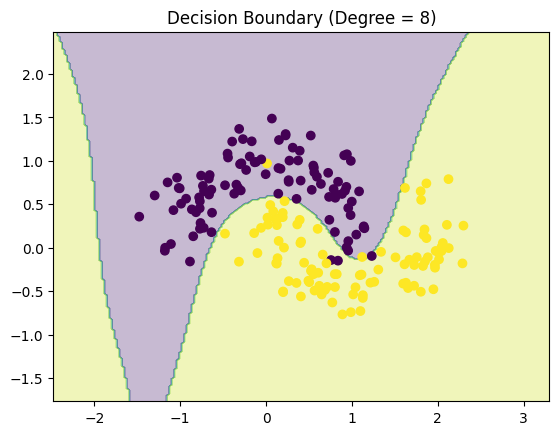

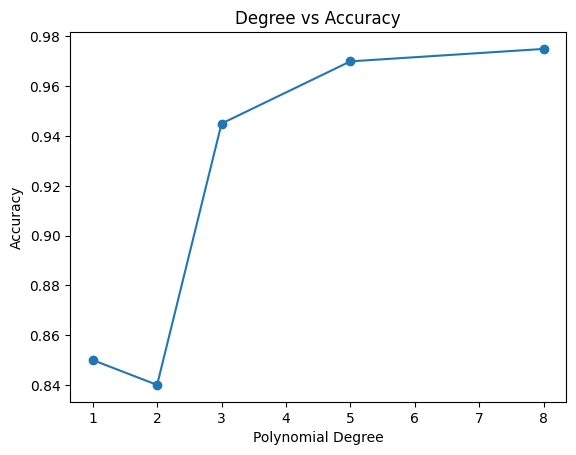

In [18]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression

# --------------------------------
# 1. Dataset
# --------------------------------
X, y = make_moons(n_samples=200, noise=0.2, random_state=42)

plt.scatter(X[:,0], X[:,1], c=y)
plt.title("Original Dataset")
plt.show()


# --------------------------------
# 2. Function for polynomial logistic regression
# --------------------------------
def run_polynomial_logistic(degree):

    print("\n==========================")
    print("Polynomial Degree:", degree)
    print("==========================")

    # create polynomial features
    poly = PolynomialFeatures(degree)

    X_poly = poly.fit_transform(X)

    print("Original shape:", X.shape)
    print("Polynomial shape:", X_poly.shape)

    # train logistic regression
    model = LogisticRegression(max_iter=10000)

    model.fit(X_poly, y)

    # predictions
    y_pred = model.predict(X_poly)

    accuracy = np.mean(y_pred == y)

    print("Accuracy:", accuracy)

    print("Intercept (w0):", model.intercept_)
    print("Weights:", model.coef_)

    # --------------------------------
    # Decision boundary
    # --------------------------------

    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    grid_poly = poly.transform(grid)

    Z = model.predict(grid_poly)

    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)

    plt.scatter(X[:,0], X[:,1], c=y)

    plt.title(f"Decision Boundary (Degree = {degree})")

    plt.show()

    return accuracy


# --------------------------------
# 3. Run with different degrees
# --------------------------------

degrees = [1,2,3,5,8]

accuracies = []

for d in degrees:

    acc = run_polynomial_logistic(d)

    accuracies.append(acc)


# --------------------------------
# 4. Plot Degree vs Accuracy
# --------------------------------

plt.plot(degrees, accuracies, marker='o')

plt.xlabel("Polynomial Degree")

plt.ylabel("Accuracy")

plt.title("Degree vs Accuracy")

plt.show()